# Isochromat-Sampling: Random vs. Deterministic

Vergleich der beiden Sampling-Strategien für die B0-Inhomogenitäts-Simulation:

| Modus | Methode | Gewichte |
|---|---|---|
| `random` | Monte-Carlo, `np.random.normal`, Seed 42 | uniform: $p_k = 1/N$ |
| `deterministic` | Shkarin & Spencer (1996), Gl. 23 | Gauß-PDF: $p_k \propto \exp(-v_k^2 / 2\sigma^2)$ |

Die deterministischen Punkte liegen gleichmäßig im Intervall $[\mu - 3.5\sigma,\; \mu + 3.5\sigma]$  
und werden mit der Gauß-PDF gewichtet (normiert auf $\sum_k p_k = 1$).

**Erwarteter Unterschied:** Der Random-Modus produziert durch ungleichmäßige Abtastung der Gauß-Linienform
systematische Hintergrundoszillationen in Multi-Puls-Sequenzen (SE, CPMG). Der deterministischen Modus
ist frei davon.

In [9]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib as mpl

from bmc.set_params import load_params
from bmc.fid.engine import BMCSim
from bmc.utils.seq.write import write_seq

## Einstellungen

In [10]:
# ── Pfade ──────────────────────────────────────────────────────────────────
wdir        = Path().resolve().parent
seq_dir     = wdir / 'seq_lib' / 'cpmg'
seq_dir.mkdir(parents=True, exist_ok=True)

config_file = wdir / 'sim_lib' / 'config_t2fit_noex.yaml'

# ── Sequenz-Parameter (identisch zu hahn_vs_cpmg.ipynb) ───────────────────
sys = pp.Opts(
    max_grad=500, grad_unit='mT/m',
    max_slew=1e9, slew_unit='T/m/s',
    rf_ringdown_time=0, rf_dead_time=0,
    rf_raster_time=1e-6, gamma=42576400, grad_raster_time=1e-6,
)

B0             = 17
t_pulse        = 2e-3
TE             = 30e-3
N_echoes       = 8
FA_refocus_deg = 120
adc_time       = 30e-3

GAMMA_HZ = sys.gamma * 1e-6
freq_hz  = B0 * GAMMA_HZ

# ── Isochromaten ───────────────────────────────────────────────────────────
low, high, n_iso = -1e-3, 1e-3, 100
z_pos = torch.sort(torch.cat((
    torch.tensor(np.linspace(low, high, n_iso)),
    torch.tensor([0.0])
))).values

# ── Analytische Echo-Zeiten ────────────────────────────────────────────────
t_echo_s = [0.5 * t_pulse]
for k in range(1, N_echoes + 1):
    c_k = (k + 0.5) * t_pulse + (k - 0.5) * TE
    t_echo_s.append(2 * c_k - t_echo_s[k - 1])
t_echo_ms = np.array(t_echo_s[1:]) * 1e3

# ── Pool-Layout ────────────────────────────────────────────────────────────
n_total_pools = 2
T2_ms         = 71.0

# ── Sampling-Modi ──────────────────────────────────────────────────────────
MODES = ['random', 'deterministic']
MODE_STYLE  = {'random': '-',  'deterministic': '--'}
MODE_ALPHA  = {'random': 1.0,  'deterministic': 0.85}
MODE_MARKER = {'random': 'o',  'deterministic': 's'}
MODE_LABELS = {
    'random':        'Random (Monte-Carlo, Seed 42)',
    'deterministic': 'Deterministic (Shkarin & Spencer 1996)',
}

cmap       = plt.get_cmap('viridis')
SEQ_COLORS = {'Hahn-Train': cmap(0.15), 'CPMG': cmap(0.75)}

print(f"Config : {config_file.name}")
print(f"TE = {TE*1e3:.0f} ms | N_echoes = {N_echoes} | FA = {FA_refocus_deg}\u00b0 | n_iso = {len(z_pos)}")

Config : config_t2fit_noex.yaml
TE = 30 ms | N_echoes = 8 | FA = 120° | n_iso = 101


## Sequenzen erstellen

Identisch zu `hahn_vs_cpmg.ipynb` — Hahn-Train (φ=0) und CPMG (φ=π/2), selbe Flipwinkel.

In [11]:
rf90 = pp.make_gauss_pulse(
    flip_angle=np.pi / 2, system=sys, duration=t_pulse,
    center_pos=0.5, freq_offset=0.0, phase_offset=0.0, return_gz=False,
)
rf90.freq_offset = 0.0

seq_files = {}
for name, phase_refocus in [('Hahn-Train', 0.0), ('CPMG', np.pi / 2)]:
    slug = name.lower().replace('-', '')
    rf170 = pp.make_gauss_pulse(
        flip_angle=np.deg2rad(FA_refocus_deg), system=sys, duration=t_pulse,
        center_pos=0.5, freq_offset=0.0, phase_offset=phase_refocus, return_gz=False,
    )
    rf170.freq_offset = 0.0
    seq = pp.Sequence()
    seq.add_block(rf90)
    seq.add_block(pp.make_delay(TE / 2))
    for k in range(N_echoes):
        seq.add_block(rf170)
        seq.add_block(pp.make_delay(TE / 2))
        if k < N_echoes - 1:
            seq.add_block(pp.make_delay(TE / 2))
    seq.add_block(pp.make_adc(num_samples=1, duration=1e-3))
    seq_id = f'{slug}_n{N_echoes}_te{int(TE*1e3):03d}ms_fa{FA_refocus_deg}'
    defs = {
        'TE': TE, 'b0': B0, 'm0_offset': 0, 'n_ETM': N_echoes,
        'seq_id_string': seq_id,
        'offsets_ppm': np.array([0]), 'num_meas': 1, 'freq': freq_hz,
    }
    sf = seq_dir / f"{seq_id}.seq"
    write_seq(seq=seq, seq_defs=defs, filename=sf, author='DANIEL MIKSCH', use_matlab_names=True)
    seq_files[name] = sf
    print(f"Sequence: {name:<12}  phi={phase_refocus/np.pi:.1f}pi  ->  {sf.name}")

Sequence: Hahn-Train    phi=0.0pi  ->  hahntrain_n8_te030ms_fa120.seq
Sequence: CPMG          phi=0.5pi  ->  cpmg_n8_te030ms_fa120.seq


## Simulation

Vier Läufe: {Hahn-Train, CPMG} × {random, deterministic}.  
Der `isochromat_mode` wird nach `load_params()` via `update_options()` überschrieben —  
die Config-Datei selbst bleibt unverändert.

In [12]:
sims = {}  # key: (seq_name, mode) -> BMCSim

for mode in MODES:
    sim_params = load_params(config_file)
    if mode == 'deterministic':
        sim_params.update_options(isochromat_mode='deterministic')

    for name, sf in seq_files.items():
        key = (name, mode)
        print(f"Simulating  {name:<12}  mode={mode} ...")
        sim = BMCSim(
            adc_time, sim_params, sf,
            z_positions=z_pos, n_backlog='ALL', webhook=False,
        )
        sim.run_fid()
        sims[key] = sim

print("\n\u2713 All 4 simulations complete.")

Simulating  Hahn-Train    mode=random ...


BMCTool simulation: 100%|██████████| 26/26 [00:05<00:00,  4.96it/s]


Simulating  CPMG          mode=random ...


BMCTool simulation: 100%|██████████| 26/26 [00:03<00:00,  6.85it/s]


Simulating  Hahn-Train    mode=deterministic ...


BMCTool simulation: 100%|██████████| 26/26 [00:03<00:00,  8.11it/s]


Simulating  CPMG          mode=deterministic ...


BMCTool simulation: 100%|██████████| 26/26 [00:04<00:00,  6.48it/s]


✓ All 4 simulations complete.


## Signalextraktion

`get_mag()` gibt die gewichtete Ensemble-Summe zurück — bei `random` mit uniformen Gewichten $1/N$,  
bei `deterministic` mit den normalisierten Gauß-PDF-Gewichten $p_k$.

In [13]:
SEARCH_WIN_MS = 8.0

results = {}  # key: (seq_name, mode) -> dict

for (name, mode), sim in sims.items():
    t_raw, _, _, m_c_iso, m_c_total = sim.get_mag()
    t_ms = t_raw.cpu().numpy() * 1e3
    mxy  = torch.abs(m_c_total).cpu().numpy()

    amps, peak_ts = [], []
    for t_e in t_echo_ms:
        mask = np.abs(t_ms - t_e) < SEARCH_WIN_MS
        if mask.sum() > 0:
            idx_max = np.where(mask)[0][np.argmax(mxy[mask])]
        else:
            idx_max = int(np.argmin(np.abs(t_ms - t_e)))
        amps.append(float(mxy[idx_max]))
        peak_ts.append(float(t_ms[idx_max]))

    # iso_weights are stored in the solver — save them for display
    weights_np = sim.bm_solver.iso_weights.cpu().numpy()

    results[(name, mode)] = {
        't_ms':      t_ms,
        'mxy':       mxy,
        'echo_amps': np.array(amps),
        'echo_ts':   np.array(peak_ts),
        'weights':   weights_np,
    }

print("Signals extracted.")

# Sanity check: weight sums
for mode in MODES:
    r = results[('CPMG', mode)]
    w = r['weights']
    print(f"  {mode:<14}  sum(weights) = {w.sum():.6f}  "
          f"min={w.min():.4f}  max={w.max():.4f}")

Signals extracted.
  random          sum(weights) = 1.000000  min=0.0099  max=0.0099
  deterministic   sum(weights) = 1.000000  min=0.0001  max=0.0279


## Gewichtsverteilung

Zeigt, wie viele Isochromaten nahe der Linienform-Mitte tatsächlich zur Mittelung beitragen.

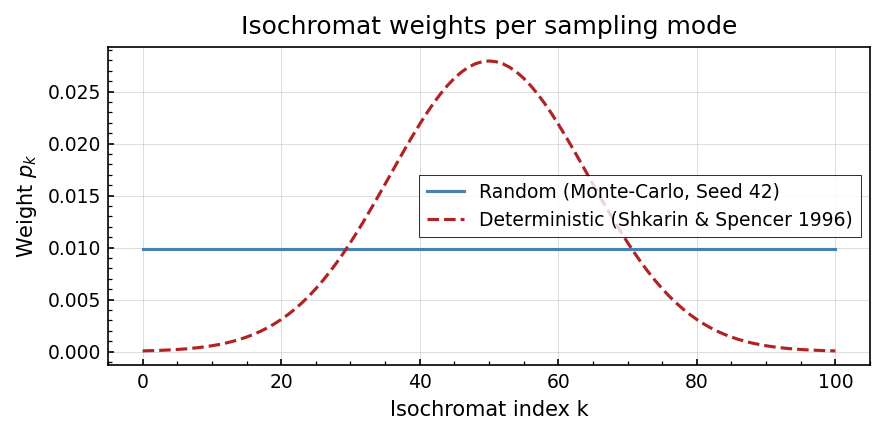

In [14]:
mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.labelsize': 10, 'legend.fontsize': 9,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.major.size': 3, 'ytick.major.size': 3,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

fig_w, ax_w = plt.subplots(figsize=(6, 3))

for mode in MODES:
    w = results[('CPMG', mode)]['weights']
    ax_w.plot(np.arange(len(w)), w,
              linestyle=MODE_STYLE[mode], label=MODE_LABELS[mode],
              color='steelblue' if mode == 'random' else 'firebrick')

ax_w.set_xlabel('Isochromat index k')
ax_w.set_ylabel('Weight $p_k$')
ax_w.set_title('Isochromat weights per sampling mode')
ax_w.grid(True, linewidth=0.4, color='gray', alpha=0.3)
leg_w = ax_w.legend(frameon=True, fancybox=False, edgecolor='black')
leg_w.get_frame().set_linewidth(0.5)
fig_w.tight_layout()
plt.show()

## Vergleichsplot

**Oben:** Zeitverlauf $|M_{xy}|$ — durchgezogen = random, gestrichelt = deterministisch.  
**Unten:** Echo-Amplituden vs. Echo-Nummer + T₂-Referenzkurve.

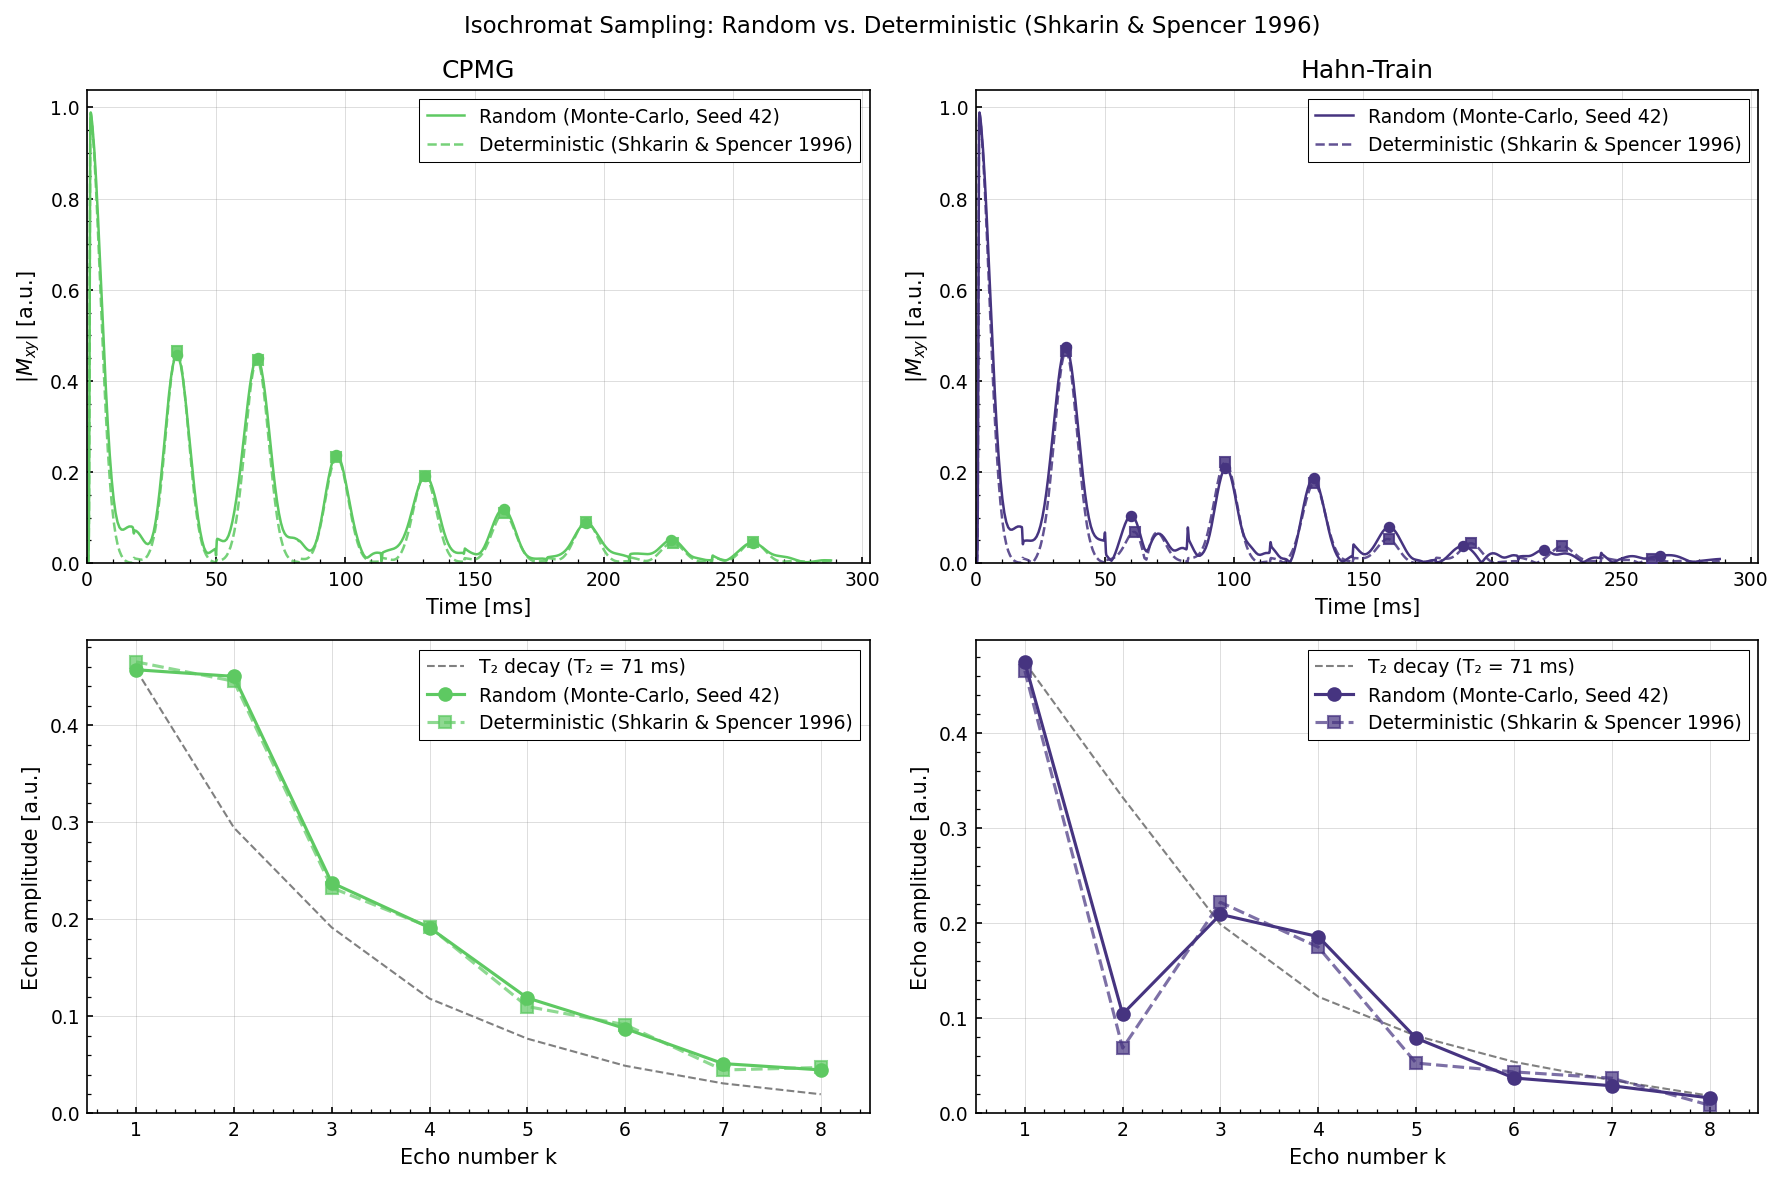

Saved to: /Users/danielmiksch/JupyterLab/optim/results/simulations/iso_mode_compare_20260519_210126


In [15]:
t_total_ms = (t_pulse + TE/2 + N_echoes*(t_pulse + TE) + adc_time) * 1e3
echo_nums  = np.arange(1, N_echoes + 1)
SEQ_NAMES  = ['CPMG', 'Hahn-Train']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, seq_name in enumerate(SEQ_NAMES):
    ax_tc = axes[0, col]
    ax_ea = axes[1, col]
    color = SEQ_COLORS[seq_name]

    # ── Zeitverlauf ───────────────────────────────────────────────────────
    for mode in MODES:
        r = results[(seq_name, mode)]
        ax_tc.plot(
            r['t_ms'], r['mxy'],
            linestyle=MODE_STYLE[mode], color=color,
            alpha=MODE_ALPHA[mode], label=MODE_LABELS[mode], linewidth=1.2,
        )
        ax_tc.plot(
            r['echo_ts'], r['echo_amps'],
            MODE_MARKER[mode], color=color,
            alpha=MODE_ALPHA[mode], markersize=4.5, zorder=5,
        )

    ax_tc.set_xlim(0, t_total_ms)
    ax_tc.set_ylim(0, None)
    ax_tc.set_title(seq_name)
    ax_tc.set_ylabel('$|M_{xy}|$ [a.u.]')
    ax_tc.set_xlabel('Time [ms]')
    ax_tc.grid(True, linewidth=0.4, color='gray', alpha=0.3)
    leg_tc = ax_tc.legend(loc='upper right', frameon=True, fancybox=False,
                          framealpha=1.0, edgecolor='black')
    leg_tc.get_frame().set_linewidth(0.5)

    # ── Echo-Amplituden ───────────────────────────────────────────────────
    r_rnd = results[(seq_name, 'random')]
    r_det = results[(seq_name, 'deterministic')]

    amp0      = r_rnd['echo_amps'][0]
    ref_curve = amp0 * np.exp(-(r_rnd['echo_ts'] - r_rnd['echo_ts'][0]) / T2_ms)
    t2_label  = f'T\u2082 decay (T\u2082 = {T2_ms:.0f} ms)'

    ax_ea.plot(echo_nums, ref_curve, '--', color='gray', linewidth=1.0, label=t2_label)
    ax_ea.plot(echo_nums, r_rnd['echo_amps'],
               'o-', color=color, alpha=1.0,  markersize=6, linewidth=1.5,
               label=MODE_LABELS['random'])
    ax_ea.plot(echo_nums, r_det['echo_amps'],
               's--', color=color, alpha=0.7, markersize=6, linewidth=1.5,
               label=MODE_LABELS['deterministic'])

    ax_ea.set_xlabel('Echo number k')
    ax_ea.set_ylabel('Echo amplitude [a.u.]')
    ax_ea.set_xlim(0.5, N_echoes + 0.5)
    ax_ea.set_ylim(0, None)
    ax_ea.set_xticks(echo_nums)
    ax_ea.grid(True, linewidth=0.4, color='gray', alpha=0.3)
    leg_ea = ax_ea.legend(loc='upper right', frameon=True, fancybox=False,
                          framealpha=1.0, edgecolor='black')
    leg_ea.get_frame().set_linewidth(0.5)

fig.suptitle(
    'Isochromat Sampling: Random vs. Deterministic (Shkarin & Spencer 1996)',
    fontsize=11,
)
fig.tight_layout()

series_label = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir  = wdir / 'results' / 'simulations' / f"iso_mode_compare_{series_label}"
results_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(results_dir / f'iso_mode_comparison_{series_label}.pdf')
fig.savefig(results_dir / f'iso_mode_comparison_{series_label}.png')
plt.show()
print(f"Saved to: {results_dir}")

## Numerischer Vergleich: Echo-Amplituden

In [16]:
for seq_name in SEQ_NAMES:
    r_rnd = results[(seq_name, 'random')]
    r_det = results[(seq_name, 'deterministic')]
    diff_amp  = r_det['echo_amps'] - r_rnd['echo_amps']
    diff_time = r_det['echo_ts']   - r_rnd['echo_ts']

    header = (
        f"{'Echo':<6}"
        f"{'t_peak_rnd [ms]':>16}"
        f"{'t_peak_det [ms]':>16}"
        f"{'dt [ms]':>10}"
        f"{'Amp_rnd':>12}"
        f"{'Amp_det':>12}"
        f"{'dAmp':>12}"
    )
    print(seq_name)
    print(header)
    print('-' * len(header))
    for k in range(N_echoes):
        print(
            f"  #{k+1:<3}"
            f"{r_rnd['echo_ts'][k]:>16.2f}"
            f"{r_det['echo_ts'][k]:>16.2f}"
            f"{diff_time[k]:>10.2f}"
            f"{r_rnd['echo_amps'][k]:>12.5f}"
            f"{r_det['echo_amps'][k]:>12.5f}"
            f"{diff_amp[k]:>+12.5f}"
        )
    print()


CPMG
Echo   t_peak_rnd [ms] t_peak_det [ms]   dt [ms]     Amp_rnd     Amp_det        dAmp
------------------------------------------------------------------------------------
  #1             34.75           34.75      0.00     0.45707     0.46517    +0.00810
  #2             66.00           66.00      0.00     0.45021     0.44520    -0.00501
  #3             96.50           96.50      0.00     0.23760     0.23247    -0.00513
  #4            130.75          130.75      0.00     0.19135     0.19200    +0.00065
  #5            161.25          161.25      0.00     0.11892     0.11008    -0.00884
  #6            193.25          193.25      0.00     0.08741     0.09133    +0.00392
  #7            226.00          226.75      0.75     0.05130     0.04470    -0.00660
  #8            258.00          258.00      0.00     0.04479     0.04728    +0.00249

Hahn-Train
Echo   t_peak_rnd [ms] t_peak_det [ms]   dt [ms]     Amp_rnd     Amp_det        dAmp
------------------------------------------------

## Interpretation

- **Kleine Differenzen** zwischen den Modi → Monte-Carlo (Seed 42) ist für dieses N und σ bereits gut gekonvergiert.
- **Sichtbare Differenzen**, vor allem bei Hahn-Train → der deterministische Modus glättet  
  Artefakte aus der ungleichmäßigen Zufallsabtastung der Gauß-Linienform.
- Der deterministischen Modus ist **reproduzierbar ohne Seed** und konvergiert bereits für kleine N.